Original feature count: 224
Expanded polynomial feature count: 25424


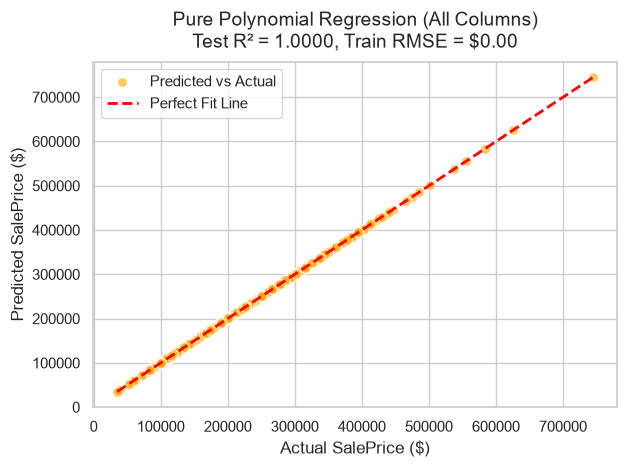

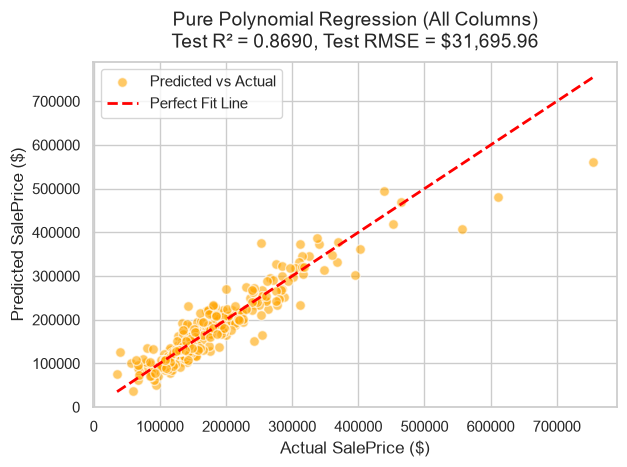

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the preprocessed dataset
df = pd.read_csv('df_EDA_minmax.csv')

# Separate features and target (dropping non-numeric target categories)
X = df.drop(columns=['SalePrice', 'Price_Category'], errors='ignore')
y = df['SalePrice']

# 2. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original feature count: {X_train.shape[1]}")

# 3. Apply Polynomial Features (Degree 2) to EVERY column
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Expanded polynomial feature count: {X_train_poly.shape[1]}")

# 4. Fit Pure Linear Regression (No Ridge/Lasso)
lr_model = LinearRegression()
lr_model.fit(X_train_poly, y_train)

# 5. Predict on Test Set
y_pred_train = lr_model.predict(X_train_poly)
y_pred_test = lr_model.predict(X_test_poly)

# 6. Plot Actual vs. Predicted values
sns.set_theme(style='whitegrid')
plt.rc('font', size=11)

plt.scatter(y_train, y_pred_train, color='orange', alpha=0.6, edgecolors='w', s=50, label='Predicted vs Actual')

# Perfect fit reference line
min_val = min(y_train.min(), y_pred_train.min())
max_val = max(y_train.max(), y_pred_train.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit Line')

plt.title(f'Pure Polynomial Regression (All Columns)\nTest R² = {r2_score(y_train, y_pred_train):.4f}, Train RMSE = ${np.sqrt(mean_squared_error(y_train, y_pred_train)):,.2f}', fontsize=14, pad=10)
plt.xlabel('Actual SalePrice ($)', fontsize=12)
plt.ylabel('Predicted SalePrice ($)', fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()

# Save the plot
plt.show()
plt.close()



sns.set_theme(style='whitegrid')
plt.rc('font', size=11)

plt.scatter(y_test, y_pred_test, color='orange', alpha=0.6, edgecolors='w', s=50, label='Predicted vs Actual')

# Perfect fit reference line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit Line')

plt.title(f'Pure Polynomial Regression (All Columns)\nTest R² = {r2_score(y_test, y_pred_test):.4f}, Test RMSE = ${np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}', fontsize=14, pad=10)
plt.xlabel('Actual SalePrice ($)', fontsize=12)
plt.ylabel('Predicted SalePrice ($)', fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()

# Save the plot
plt.show()
plt.close()